# RetainIQ — Phase 6.2: Market-Level Retention & Revenue Analysis

I will measure retention patterns across states and cities, apply a minimum market-size threshold, and identify markets with high churn, high historical revenue exposure, and high customer value.

## Metric definitions

**Churn rate** = churned customers / total customers in the market.

**Revenue at risk** in this phase is a historical proxy: the recorded `total_revenue` associated with customers already labeled as churned. It is not a forecast of future revenue loss.

In [3]:
from getpass import getpass
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
from mysql.connector import Error
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

MYSQL_CONFIG = {
    "host": "localhost",
    "port": 3306,
    "user": "retainiq_user",
    "password": getpass("Enter MySQL password for retainiq_user: "),
    "database": "retainiq",
}

def get_connection():
    return mysql.connector.connect(**MYSQL_CONFIG)

def run_query(query, params=None):
    connection = None
    cursor = None
    try:
        connection = get_connection()
        cursor = connection.cursor(dictionary=True)
        cursor.execute(query, params or ())
        rows = cursor.fetchall()
        return pd.DataFrame(rows)
    except Error as exc:
        raise RuntimeError(f"MySQL query failed: {exc}") from exc
    finally:
        if cursor:
            cursor.close()
        if connection and connection.is_connected():
            connection.close()

def print_result(message):
    print(f"Result: {message}")


## 1. Load the market analysis dataset

In [4]:
market_query = """
SELECT
    f.customer_id,
    f.monthly_charge,
    f.total_revenue,
    f.satisfaction_score,
    f.cltv,
    f.churn_label,
    l.state,
    l.city,
    l.zip_code,
    l.latitude,
    l.longitude,
    l.population,
    a.contract,
    a.payment_method,
    s.internet_type
FROM fact_customer_status f
JOIN dim_location l ON f.customer_id = l.customer_id
JOIN dim_account a ON f.customer_id = a.customer_id
JOIN dim_services s ON f.customer_id = s.customer_id;
"""

market_df = run_query(market_query)

for column in [
    "monthly_charge", "total_revenue", "satisfaction_score",
    "cltv", "zip_code", "latitude", "longitude", "population"
]:
    market_df[column] = pd.to_numeric(market_df[column], errors="coerce")

print_result(f"I loaded {len(market_df):,} customers for market-level retention analysis.")
display(market_df.head())

Result: I loaded 7,043 customers for market-level retention analysis.


,customer_id,monthly_charge,total_revenue,satisfaction_score,cltv,churn_label,state,city,zip_code,latitude,longitude,population,contract,payment_method,internet_type
0,0002-ORFBO,65.60,974.81,3,2205,No,California,Frazier Park,93225,34.83,-119.00,4498,One Year,Credit Card,Cable
1,0003-MKNFE,59.90,610.28,5,5414,No,California,Glendale,91206,34.16,-118.20,31297,Month-to-Month,Credit Card,Cable
2,0013-MHZWF,69.40,722.38,3,5108,No,California,Midpines,95345,37.58,-119.97,433,Month-to-Month,Credit Card,Cable
3,0016-QLJIS,90.45,"7,807.80",3,5509,No,California,Sheridan,95681,38.98,-121.35,1219,Two Year,Credit Card,Cable
4,0017-DINOC,45.20,"2,460.55",4,5435,No,California,Rancho Santa Fe,92091,32.99,-117.21,1072,Two Year,Credit Card,Cable


### Result & conclusion

The market dataset combines customer value and retention outcomes with geography. I can now calculate market-level retention profiles without changing the customer grain.

## 2. Build the state-level retention profile

In [5]:
state_profile = (
    market_df.groupby("state", dropna=False)
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churn_label", lambda s: (s == "Yes").sum()),
        avg_cltv=("cltv", "mean"),
        total_revenue=("total_revenue", "sum"),
        avg_monthly_charge=("monthly_charge", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)
state_profile["churn_rate_pct"] = (
    state_profile["churned_customers"] / state_profile["customers"] * 100
)
state_revenue_risk = (
    market_df.loc[market_df["churn_label"] == "Yes"]
    .groupby("state")["total_revenue"].sum()
)
state_profile["revenue_at_risk"] = state_revenue_risk.reindex(state_profile.index).fillna(0)
state_profile["share_of_customers_pct"] = state_profile["customers"] / len(market_df) * 100
state_profile = state_profile.round(2)

display(state_profile.sort_values("churn_rate_pct", ascending=False))
print_result(f"I created {len(state_profile):,} state retention profiles. The largest state market has {int(state_profile['customers'].max()):,} customers.")

,customers,churned_customers,avg_cltv,total_revenue,avg_monthly_charge,avg_satisfaction,churn_rate_pct,revenue_at_risk,share_of_customers_pct
state,,,,,,,,,
California,7043,1869,"4,400.30","21,371,131.69",64.76,3.24,26.54,"3,684,459.82",100.00


Result: I created 1 state retention profiles. The largest state market has 7,043 customers.


### Result & conclusion

The state profile lets me compare churn rate, customer value, satisfaction, and historical revenue exposure together. I use this table as the broader geographic retention baseline.

## 3. Build the city-level retention profile

In [6]:
city_profile = (
    market_df.groupby(["state", "city"], dropna=False)
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churn_label", lambda s: (s == "Yes").sum()),
        avg_cltv=("cltv", "mean"),
        total_revenue=("total_revenue", "sum"),
        avg_monthly_charge=("monthly_charge", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)
city_profile["churn_rate_pct"] = (
    city_profile["churned_customers"] / city_profile["customers"] * 100
)
city_revenue_risk = (
    market_df.loc[market_df["churn_label"] == "Yes"]
    .groupby(["state", "city"])["total_revenue"].sum()
)
city_profile["revenue_at_risk"] = city_revenue_risk.reindex(city_profile.index).fillna(0)
city_profile = city_profile.round(2)

display(city_profile.head(20))
print_result(f"I created {len(city_profile):,} city profiles before applying the market-size threshold.")

customers  churned_customers  avg_cltv  \
state      city                                                   
California Acampo                4                  3  5,254.50   
           Acton                 4                  0  4,711.00   
           Adelanto              5                  1  4,364.80   
           Adin                  4                  2  3,990.50   
           Agoura Hills          5                  2  4,507.20   
           Aguanga               4                  1  4,501.00   
           Ahwahnee              4                  1  3,666.00   
           Alameda               8                  0  4,089.00   
           Alamo                 4                  0  5,193.75   
           Albany                4                  2  4,286.50   
           Albion                4                  0  3,742.00   
           Alderpoint            4                  1  5,122.50   
           Alhambra              9                  3  3,815.89   
           Aliso Viejo           4                  0  5,056.25   
           Alleghany             4                  0  4,193.50   
           Alpaugh               4                  3  4,350.75   
           Alpine                5                  3  4,616.80   
           Alta                  4                  0  4,450.50   
           Altadena              5                  1  4,095.20   
           Alturas               3                  0  5,261.33   

                         total_revenue  avg_monthly_charge  avg_satisfaction  \
state      city                                                                
California Acampo            18,107.96              103.11              2.00   
           Acton             12,156.36               69.53              4.25   
           Adelanto          18,235.49               56.56              3.60   
           Adin               5,539.38               57.02              2.50   
           Agoura Hills      10,641.88               48.99              2.80   
           Aguanga           10,033.52               52.38              2.50   
           Ahwahnee           9,336.36               49.16              3.50   
           Alameda           14,092.66               22.47              4.62   
           Alamo             30,424.46               82.00              4.00   
           Albany            15,788.32               78.59              2.75   
           Albion             8,536.12               72.58              4.00   
           Alderpoint        15,541.53               74.45              3.50   
           Alhambra           9,292.61               55.78              3.44   
           Aliso Viejo       26,807.83               86.35              3.00   
           Alleghany          4,328.21               42.91              3.50   
           Alpaugh           11,860.65               69.99              2.00   
           Alpine            11,379.36               64.98              2.60   
           Alta               9,490.16               50.49              3.75   
           Altadena           9,484.84               57.00              3.40   
           Alturas            1,819.33               63.45              3.67   

                         churn_rate_pct  revenue_at_risk  
state      city                                           
California Acampo                 75.00        10,471.36  
           Acton                   0.00             0.00  
           Adelanto               20.00         4,005.02  
           Adin                   50.00         2,457.91  
           Agoura Hills           40.00         9,785.04  
           Aguanga                25.00           595.48  
           Ahwahnee               25.00           117.46  
           Alameda                 0.00             0.00  
           Alamo                   0.00             0.00  
           Albany                 50.00         4,402.92  
           Albion                  0.00             0.00  
           Alderpoint 

Result: I created 1,106 city profiles before applying the market-size threshold.


### Result & conclusion

City profiles provide more granular retention detail, but small markets can produce unstable churn percentages. I handle that by filtering city comparisons in the next step.

## 4. Apply a minimum market-size threshold

In [7]:
minimum_market_size = 25
city_profile_filtered = city_profile[city_profile["customers"] >= minimum_market_size].copy()

print_result(
    f"I retained {len(city_profile_filtered):,} city markets with at least {minimum_market_size} customers for churn-rate comparison."
)

Result: I retained 27 city markets with at least 25 customers for churn-rate comparison.


### Result & conclusion

The threshold reduces the influence of very small markets where one or two customers can move the churn rate sharply. I am using the rule for comparability, not as a statement about market importance.

## 5. Identify markets with the highest churn rates

In [8]:
highest_churn_markets = (
    city_profile_filtered
    .sort_values(["churn_rate_pct", "customers"], ascending=[False, False])
    .head(20)
)

display(highest_churn_markets[[
    "customers", "churned_customers", "churn_rate_pct", "avg_cltv", "revenue_at_risk"
]])
print_result(
    f"The highest observed city churn rate among qualifying markets is {highest_churn_markets['churn_rate_pct'].iloc[0]:.2f}%."
)

customers  churned_customers  churn_rate_pct  \
state      city                                                           
California San Diego             285                185           64.91   
           Fallbrook              43                 26           60.47   
           Temecula               38                 22           57.89   
           Modesto                28                 12           42.86   
           Santa Barbara          28                 10           35.71   
           Glendale               40                 13           32.50   
           Torrance               25                  8           32.00   
           Escondido              51                 16           31.37   
           Pasadena               30                  9           30.00   
           San Francisco         104                 31           29.81   
           San Bernardino         28                  8           28.57   
           Berkeley               32                  9           28.12   
           Stockton               44                 12           27.27   
           Los Angeles           293                 78           26.62   
           San Jose              112                 29           25.89   
           Long Beach             60                 15           25.00   
           Oakland                52                 13           25.00   
           Riverside              32                  8           25.00   
           Anaheim                28                  7           25.00   
           Sacramento            108                 26           24.07   

                           avg_cltv  revenue_at_risk  
state      city                                       
California San Diego       4,345.09       385,446.39  
           Fallbrook       4,531.28        34,691.78  
           Temecula        4,367.87        44,102.41  
           Modesto         4,364.64        11,909.92  
           Santa Barbara   4,198.11        46,033.71  
           Glendale        4,355.95        10,622.55  
           Torrance        4,606.20        33,534.79  
           Escondido       4,388.86        38,869.89  
           Pasadena        4,226.13        26,383.57  
           San Francisco   4,335.46        56,894.27  
           San Bernardino  4,426.25        23,726.13  
           Berkeley        4,527.31         8,517.45  
           Stockton        4,371.18        19,686.28  
           Los Angeles     4,369.85       147,090.46  
           San Jose        4,233.38        44,393.49  
           Long Beach      4,494.22        28,550.22  
           Oakland         4,334.40        22,515.74  
           Riverside       4,573.72         6,875.76  
           Anaheim         4,069.68         3,592.34  
           Sacramento      4,540.66        59,449.20

Result: The highest observed city churn rate among qualifying markets is 64.91%.


### Result & conclusion

These markets show the strongest observed churn rates among adequately sized city markets. I should inspect their customer mix and value before treating them as retention priorities.

## 6. Identify markets with the largest historical revenue exposure

In [9]:
highest_revenue_risk = (
    city_profile_filtered
    .sort_values("revenue_at_risk", ascending=False)
    .head(20)
)

display(highest_revenue_risk[[
    "customers", "churned_customers", "churn_rate_pct", "avg_cltv", "revenue_at_risk"
]])
print_result(
    f"The largest historical revenue exposure among qualifying markets is {highest_revenue_risk['revenue_at_risk'].iloc[0]:,.2f}."
)

customers  churned_customers  churn_rate_pct  \
state      city                                                           
California San Diego             285                185           64.91   
           Los Angeles           293                 78           26.62   
           Sacramento            108                 26           24.07   
           San Francisco         104                 31           29.81   
           Santa Barbara          28                 10           35.71   
           San Jose              112                 29           25.89   
           Temecula               38                 22           57.89   
           Escondido              51                 16           31.37   
           Fallbrook              43                 26           60.47   
           Torrance               25                  8           32.00   
           Fresno                 61                 13           21.31   
           Long Beach             60                 15           25.00   
           Pasadena               30                  9           30.00   
           San Bernardino         28                  8           28.57   
           Oakland                52                 13           25.00   
           Stockton               44                 12           27.27   
           Santa Monica           25                  5           20.00   
           Whittier               30                  5           16.67   
           Burbank                25                  6           24.00   
           Modesto                28                 12           42.86   

                           avg_cltv  revenue_at_risk  
state      city                                       
California San Diego       4,345.09       385,446.39  
           Los Angeles     4,369.85       147,090.46  
           Sacramento      4,540.66        59,449.20  
           San Francisco   4,335.46        56,894.27  
           Santa Barbara   4,198.11        46,033.71  
           San Jose        4,233.38        44,393.49  
           Temecula        4,367.87        44,102.41  
           Escondido       4,388.86        38,869.89  
           Fallbrook       4,531.28        34,691.78  
           Torrance        4,606.20        33,534.79  
           Fresno          4,362.62        29,607.42  
           Long Beach      4,494.22        28,550.22  
           Pasadena        4,226.13        26,383.57  
           San Bernardino  4,426.25        23,726.13  
           Oakland         4,334.40        22,515.74  
           Stockton        4,371.18        19,686.28  
           Santa Monica    4,784.20        15,450.40  
           Whittier        4,772.93        15,134.48  
           Burbank         4,529.00        14,443.55  
           Modesto         4,364.64        11,909.92

Result: The largest historical revenue exposure among qualifying markets is 385,446.39.


### Result & conclusion

Revenue exposure and churn rate answer different questions. A large market can have substantial historical revenue exposure because it has many churned customers even when its churn rate is not the highest.

## 7. Identify markets with the highest average CLTV

In [10]:
highest_value_markets = (
    city_profile_filtered
    .sort_values("avg_cltv", ascending=False)
    .head(20)
)

display(highest_value_markets[[
    "customers", "churned_customers", "churn_rate_pct", "avg_cltv", "revenue_at_risk"
]])
print_result(
    f"The highest average CLTV among qualifying city markets is {highest_value_markets['avg_cltv'].iloc[0]:,.2f}."
)

customers  churned_customers  churn_rate_pct  \
state      city                                                           
California Inglewood              25                  5           20.00   
           Santa Monica           25                  5           20.00   
           Whittier               30                  5           16.67   
           Bakersfield            39                  2            5.13   
           Torrance               25                  8           32.00   
           Riverside              32                  8           25.00   
           Sacramento            108                 26           24.07   
           Fallbrook              43                 26           60.47   
           Burbank                25                  6           24.00   
           Berkeley               32                  9           28.12   
           Long Beach             60                 15           25.00   
           Irvine                 28                  5           17.86   
           San Bernardino         28                  8           28.57   
           Escondido              51                 16           31.37   
           Stockton               44                 12           27.27   
           Los Angeles           293                 78           26.62   
           Temecula               38                 22           57.89   
           Modesto                28                 12           42.86   
           Fresno                 61                 13           21.31   
           Glendale               40                 13           32.50   

                           avg_cltv  revenue_at_risk  
state      city                                       
California Inglewood       5,006.24         7,035.43  
           Santa Monica    4,784.20        15,450.40  
           Whittier        4,772.93        15,134.48  
           Bakersfield     4,609.41           137.56  
           Torrance        4,606.20        33,534.79  
           Riverside       4,573.72         6,875.76  
           Sacramento      4,540.66        59,449.20  
           Fallbrook       4,531.28        34,691.78  
           Burbank         4,529.00        14,443.55  
           Berkeley        4,527.31         8,517.45  
           Long Beach      4,494.22        28,550.22  
           Irvine          4,466.64        11,021.48  
           San Bernardino  4,426.25        23,726.13  
           Escondido       4,388.86        38,869.89  
           Stockton        4,371.18        19,686.28  
           Los Angeles     4,369.85       147,090.46  
           Temecula        4,367.87        44,102.41  
           Modesto         4,364.64        11,909.92  
           Fresno          4,362.62        29,607.42  
           Glendale        4,355.95        10,622.55

Result: The highest average CLTV among qualifying city markets is 5,006.24.


### Result & conclusion

High-value markets deserve a separate view because a high CLTV market can matter strategically even if it does not have the highest customer count.

## 8. Compare market size with churn rate

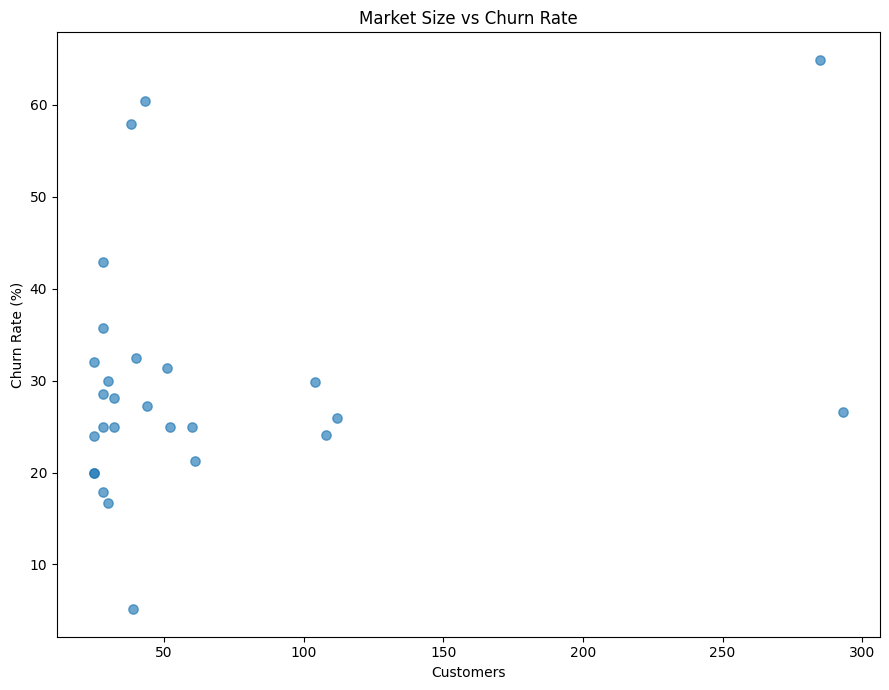

Result: The Pearson correlation between market size and churn rate is 0.308; this is descriptive and does not establish causation.


In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    city_profile_filtered["customers"],
    city_profile_filtered["churn_rate_pct"],
    s=45,
    alpha=0.65
)
ax.set_title("Market Size vs Churn Rate")
ax.set_xlabel("Customers")
ax.set_ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

corr = city_profile_filtered[["customers", "churn_rate_pct"]].corr().iloc[0,1]
print_result(f"The Pearson correlation between market size and churn rate is {corr:.3f}; this is descriptive and does not establish causation.")

### Result & conclusion

This plot shows whether large and small markets display similar retention patterns. The correlation is a descriptive statistic, not evidence that market size causes churn.

## 9. Compare market value with historical revenue exposure

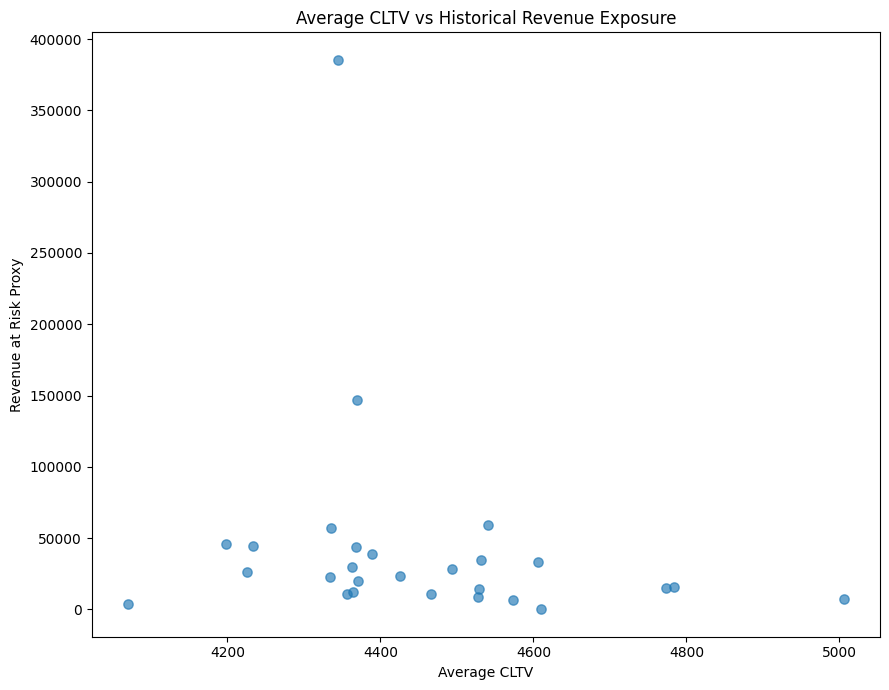

Result: The Pearson correlation between average CLTV and historical revenue exposure is -0.191.


In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    city_profile_filtered["avg_cltv"],
    city_profile_filtered["revenue_at_risk"],
    s=45,
    alpha=0.65
)
ax.set_title("Average CLTV vs Historical Revenue Exposure")
ax.set_xlabel("Average CLTV")
ax.set_ylabel("Revenue at Risk Proxy")
plt.tight_layout()
plt.show()

corr = city_profile_filtered[["avg_cltv", "revenue_at_risk"]].corr().iloc[0,1]
print_result(f"The Pearson correlation between average CLTV and historical revenue exposure is {corr:.3f}.")

### Result & conclusion

This comparison helps me find markets that combine customer value with a meaningful amount of historical revenue exposure. I use it later with segment-level information for a more focused view.

## 10. Export market-level outputs

In [13]:
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

state_profile.to_csv(output_dir / "state_retention_profile.csv")
city_profile.to_csv(output_dir / "city_retention_profile.csv")
highest_churn_markets.to_csv(output_dir / "highest_churn_markets.csv")
highest_revenue_risk.to_csv(output_dir / "highest_revenue_risk_markets.csv")
highest_value_markets.to_csv(output_dir / "highest_value_markets.csv")

print_result("I exported the state profile, city profile, and the three market-ranking artifacts for reuse in Phase 6.3 and Phase 6.4.")

Result: I exported the state profile, city profile, and the three market-ranking artifacts for reuse in Phase 6.3 and Phase 6.4.


### Result & conclusion

The market-level outputs are now reusable files rather than notebook-only results. Phase 6.3 can join them conceptually with the Phase 5 customer segments without rebuilding the market calculations.

# Phase 6.2 conclusion

I now have state- and city-level retention profiles, a controlled city-market comparison rule, and separate views of churn rate, customer value, and historical revenue exposure. The next step is to combine geography with the customer segments from Phase 5.